# Customer Churn Analysis

In [ ]:
pip install pandas numpy matplotlib seaborn scikit-learn

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv(r"C:\Users\JANHAVI\Desktop\FSDS1\Dataset\Churn_Modelling.csv")

print(df.head())
print(df.info())

   RowNumber  CustomerId   Surname  CreditScore Geography  Gender  Age  \
0          1    15634602  Hargrave          619    France  Female   42   
1          2    15647311      Hill          608     Spain  Female   41   
2          3    15619304      Onio          502    France  Female   42   
3          4    15701354      Boni          699    France  Female   39   
4          5    15737888  Mitchell          850     Spain  Female   43   

   Tenure    Balance  NumOfProducts  HasCrCard  IsActiveMember  \
0       2       0.00              1          1               1   
1       1   83807.86              1          0               1   
2       8  159660.80              3          1               0   
3       1       0.00              2          0               0   
4       2  125510.82              1          1               1   

   EstimatedSalary  Exited  
0        101348.88       1  
1        112542.58       0  
2        113931.57       1  
3         93826.63       0  
4         790

# Data Cleaning

In [3]:
# Missing Value
print(df.isnull().sum())

RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64


In [7]:
print(df.columns)

Index(['RowNumber', 'CustomerId', 'Surname', 'CreditScore', 'Geography',
       'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember', 'EstimatedSalary', 'Exited'],
      dtype='object')


In [8]:
df["Balance"] = df["Balance"].fillna(df["Balance"].mean())

In [9]:
df["Gender"] = df["Gender"].map({"Male":1,"Female":0})

In [10]:
df = pd.get_dummies(df, columns=["Geography"], drop_first=True)

In [11]:
# Churn Count
df["Exited"].value_counts()

Exited
0    7963
1    2037
Name: count, dtype: int64

In [12]:
# Averagee Customer who left
df.groupby("Exited")["Age"].mean()

Exited
0    37.408389
1    44.837997
Name: Age, dtype: float64

In [14]:
df["Exited"] = df["Exited"].astype(int)

In [15]:
df["Exited"].unique()

array([1, 0])

# Analysis

In [16]:
df["Exited"].value_counts()

Exited
0    7963
1    2037
Name: count, dtype: int64

# Exploratory Data Analysis

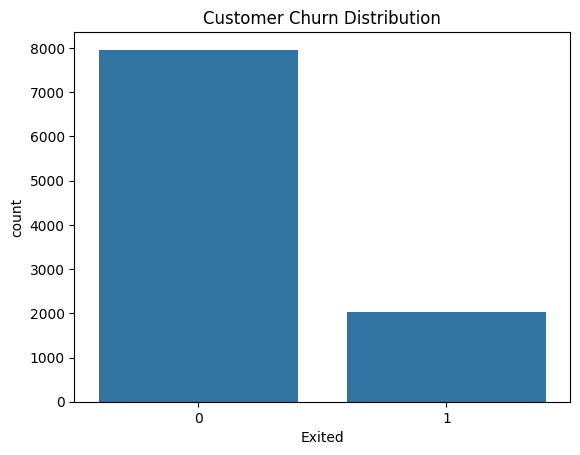

In [17]:
#  Churn Distribution
sns.countplot(x="Exited", data=df)

plt.title("Customer Churn Distribution")

plt.show()

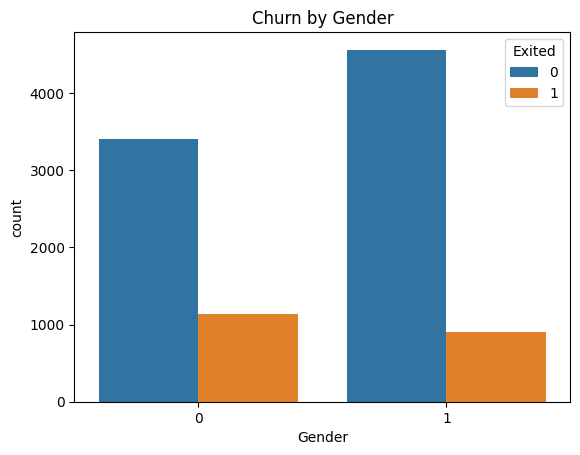

In [20]:
# Churn Gender
sns.countplot(x="Gender", hue="Exited",data=df)
plt.title("Churn by Gender")
plt.show()

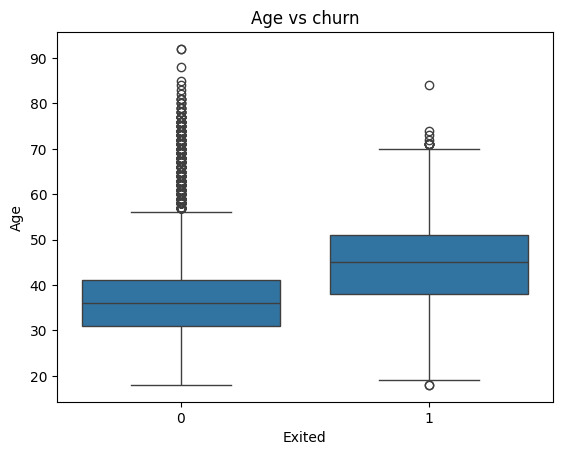

In [22]:
# Age Vs Churn 
sns.boxplot(x="Exited",y="Age",data=df)
plt.title("Age vs churn")
plt.show()

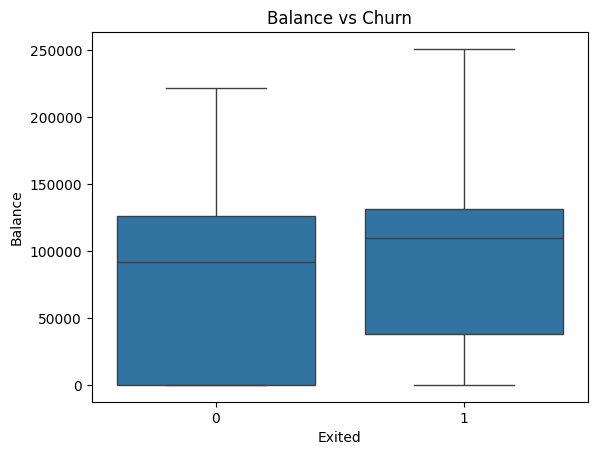

In [24]:
# Balance By Gender
sns.boxplot(x="Exited", y="Balance", data=df)

plt.title("Balance vs Churn")

plt.show()

# Feature Selection

In [25]:
df = df.drop(["RowNumber", "CustomerId", "Surname"], axis=1)

# Convert Categorical Variable

In [26]:
df = pd.get_dummies(df,drop_first=True)

# Split Data

In [28]:
from sklearn.model_selection import train_test_split
X = df.drop("Exited",axis=1)
y = df["Exited"]

X_train,X_test, y_train,y_test = train_test_split(X,y, test_size=0.2, random_state=42)

# Train Machine Learning Model

In [29]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(max_iter = 1000)
model.fit(X_train,y_train)

c:\Users\JANHAVI\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [30]:
y_pred = model.predict(X_test)

# Model Evaluation

In [34]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
print("Accuracy:", accuracy_score(y_test,y_pred))

print("Confusion Matrix")
print(confusion_matrix(y_test,y_pred))

print("Classification Report")
print(classification_report(y_test, y_pred))

Accuracy: 0.815
Confusion Matrix
[[1543   64]
 [ 306   87]]
Classification Report
              precision    recall  f1-score   support

           0       0.83      0.96      0.89      1607
           1       0.58      0.22      0.32       393

    accuracy                           0.81      2000
   macro avg       0.71      0.59      0.61      2000
weighted avg       0.78      0.81      0.78      2000



# Feature Importance

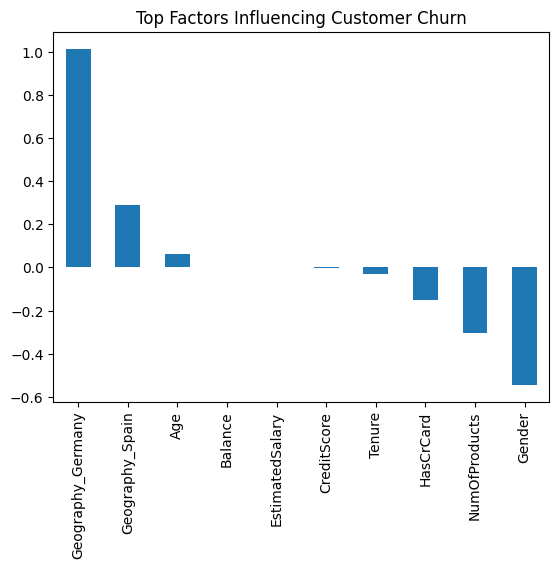

In [35]:
importance = pd.Series(model.coef_[0], index=X.columns)

importance.sort_values(ascending=False).head(10).plot(kind="bar")

plt.title("Top Factors Influencing Customer Churn")

plt.show()

In [36]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

# Load dataset
df = pd.read_csv(r"C:\Users\JANHAVI\Desktop\FSDS1\Dataset\Churn_Modelling.csv")

# Drop unnecessary columns
df = df.drop(["RowNumber", "CustomerId", "Surname"], axis=1)

# Convert categorical variables
df = pd.get_dummies(df, drop_first=True)

# Split data
X = df.drop("Exited", axis=1)
y = df["Exited"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train model
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

c:\Users\JANHAVI\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


# Prediction

In [37]:
def predict_churn(CreditScore, Age, Tenure, Balance, NumOfProducts,
                  HasCrCard, IsActiveMember, EstimatedSalary,
                  Geography_Germany, Geography_Spain, Gender_Male):

    input_data = [[CreditScore, Age, Tenure, Balance, NumOfProducts,
                   HasCrCard, IsActiveMember, EstimatedSalary,
                   Geography_Germany, Geography_Spain, Gender_Male]]

    prediction = model.predict(input_data)[0]

    if prediction == 1:
        return "Customer is likely to CHURN"
    else:
        return "Customer will STAY"

# Gradio

In [38]:
import gradio as gr

interface = gr.Interface(
    fn=predict_churn,
    inputs=[
        gr.Number(label="Credit Score"),
        gr.Number(label="Age"),
        gr.Number(label="Tenure"),
        gr.Number(label="Balance"),
        gr.Number(label="Number of Products"),
        gr.Number(label="Has Credit Card (1/0)"),
        gr.Number(label="Is Active Member (1/0)"),
        gr.Number(label="Estimated Salary"),
        gr.Number(label="Geography Germany (1/0)"),
        gr.Number(label="Geography Spain (1/0)"),
        gr.Number(label="Gender Male (1/0)")
    ],
    outputs="text",
    title="Bank Customer Churn Prediction",
    description="Enter customer details to predict churn"
)

interface.launch()

c:\Users\JANHAVI\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


* Running on local URL:  http://127.0.0.1:7860
* To create a public link, set `share=True` in `launch()`.


c:\Users\JANHAVI\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
c:\Users\JANHAVI\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


Created dataset file at: .gradio\flagged\dataset1.csv
